In [9]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_algebra import QR_dec


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
plt.rcParams.update({
    "text.usetex": True,           # Attiva l'uso di LaTeX per tutto il testo
    "font.family": "serif",        # Usa un font Serif per il testo normale
    "font.serif": ["Palatino"],    # Specifica Palatino (molto simile a quello in foto)
    "axes.labelsize": 16,          # Dimensione font etichette assi
    "font.size": 14,                # Dimensione font generale
    "legend.fontsize": 14,         # Dimensione font legenda
    "xtick.labelsize": 13,         # Dimensione numeri asse x
    "ytick.labelsize": 13,         # Dimensione numeri asse y
    "figure.figsize": (8, 6),      # Dimensione predefinita della figura
    "figure.dpi": 100,             # Risoluzione
    
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
})

## **Condition number of *Vandermonde Matrix***

Using the QR decomposition we can estimate the condition number of the Vandermonde matrix as it grows in size.

Recall in fact that given $A = QR$, since $Q$ preserve the L2 norm, we can estimate the condition number as $\kappa = |R_{11}/R_{nn}|$.

By sampling the interval $x \in [-1, 1]$ with $n$ equidistant points, study the convergence as a function of $n$ in the range $n \in [4, 16]$ by plotting the condition number in logarithmic scale.

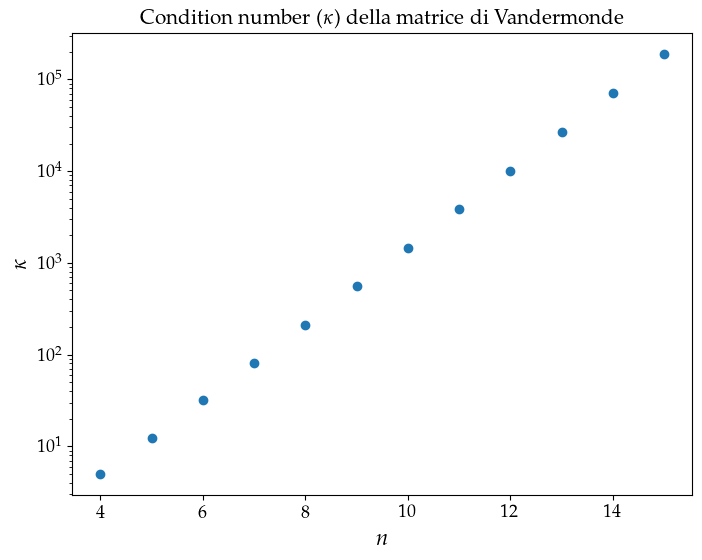

In [11]:
out_vector = []
np_range = np.arange(4, 16)
for dim in np_range:
    V = np.ones((dim, dim))
    x = np.linspace(-1, 1, dim)
    for col in range(dim):
        V[:, col] = x**col
    Q, R = QR_dec(V)
    k = abs(R[0,0] / R[dim-1,dim-1])
    out_vector.append(k)

plt.scatter(np_range, out_vector)
plt.title(r'Condition number ($\kappa$) della matrice di Vandermonde', size=15)
plt.xlabel(r'$n$')
plt.ylabel(r'$\kappa$')
plt.yscale('log')
plt.savefig('plots/Vandermonde_cond.png', dpi=300)
plt.show()

    

## **Lagrange Interpolation**
Write a program performing Lagrange interpolation. In this case since the weights are precomputed it is particularly useful to build a class which stores internally the weights.

Test the function on the following data sets
```Python
1. Dataset A
xA = np.array([0, 2, 3, 5, 7, 8, 10])
fA = np.array([0, 2, 2.5, 4, 2.5, 2, 0])

2. Dataset B
xB = np.array([0, 2, 3, 4, 5, 6, 7, 8, 10])
fB = np.array([0, 2, 2.5, 2, 4, 2, 2.5, 2, 0])

3. Dataset C
xC = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
fC = np.array([0, 1.5, 2, 2.5, 2, 4, 2, 2.5, 2, 1.5, 0])

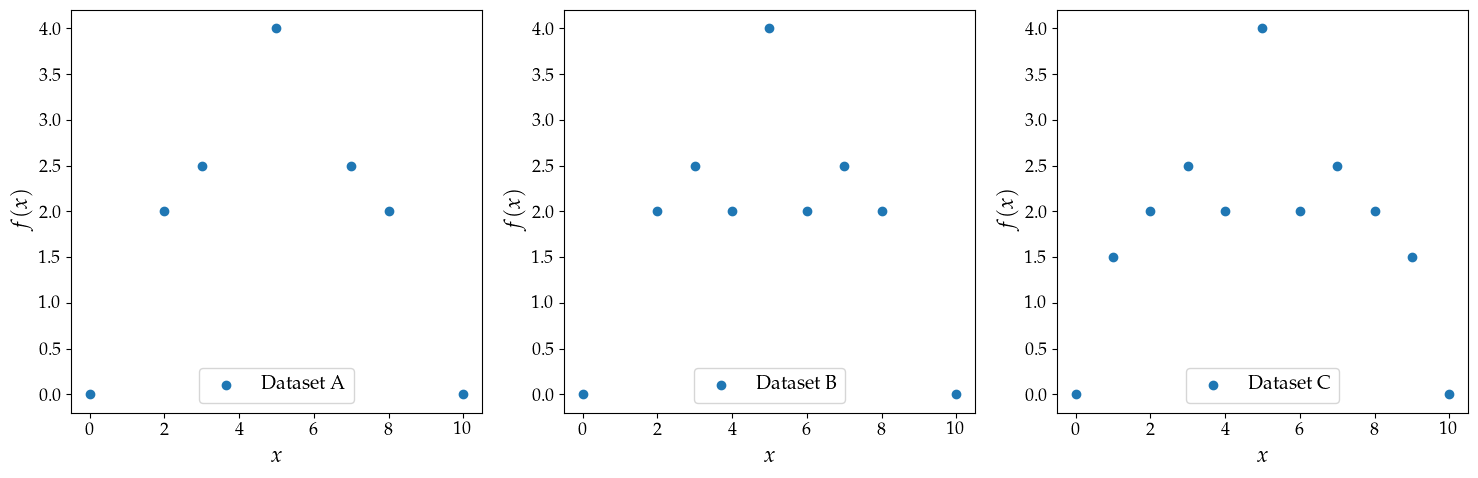

In [12]:
xA = np.array([0, 2, 3, 5, 7, 8, 10], dtype=float)
fA = np.array([0, 2, 2.5, 4, 2.5, 2, 0], dtype=float)

xB = np.array([0, 2, 3, 4, 5, 6, 7, 8, 10], dtype=float)
fB = np.array([0, 2, 2.5, 2, 4, 2, 2.5, 2, 0], dtype=float)

xC = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
fC = np.array([0, 1.5, 2, 2.5, 2, 4, 2, 2.5, 2, 1.5, 0], dtype=float)

x_arr = [xA, xB, xC]
f_arr = [fA, fB, fC]
names = [r'Dataset A', r'Dataset B', r'Dataset C']

def plot_lag(x, y, name):
    fig, ax = plt.subplots(1, 3, figsize=(15,5))
    for i in range(len(x)):
        ax[i].scatter(x[i], y[i], label=name[i])
        ax[i].set_xlabel(r'$x$')
        ax[i].set_ylabel(r'$f(x)$')
        ax[i].legend(loc='lower center')
    plt.tight_layout()
    plt.savefig('plots/Lagrange_dataset_plot.png', dpi=300)
    plt.show()

plot_lag(x_arr, f_arr, names)

In [13]:
class Lagrange:
    def __init__(self, x, f):
        self.x = x
        self.f = f
        n = len(x)
        w_arr = []
        for k in range(n):
            mask = np.ones(len(x), dtype=bool)
            mask[k] = False
            wk = np.prod((x[k] - x[mask] + 1e-15))**(-1)
            w_arr.append(wk)
        self.w = np.array(w_arr)

    def __call__(self, x0):
        frac = self.w / (x0 - self.x)
        return np.sum(self.f * frac) / np.sum(frac)


def lagrange_int(x, f, N_points=1000):
    lag = Lagrange(x, f)
    xoff = 0.001*(x[-1] - x[0])
    x_in = np.linspace(x[0]-xoff, x[-1]+xoff, N_points)
    y_in = []
    for i in x_in:
        y_in.append(lag(i))
    return x_in, np.array(y_in)



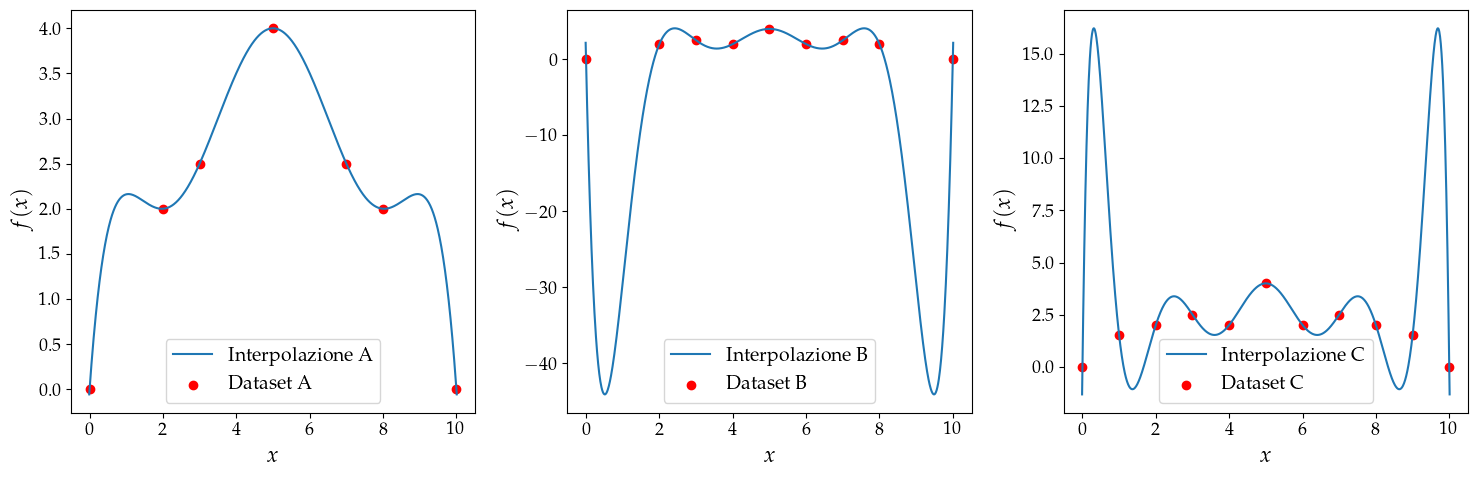

In [14]:
xALag, YALag = lagrange_int(xA, fA)
xBLag, YBLag = lagrange_int(xB, fB)
xCLag, YCLag = lagrange_int(xC, fC)

xLag_arr = [xALag, xBLag, xCLag]
fLag_arr = [YALag, YBLag, YCLag]

names = [r'A', r'B', r'C']

def plot_lag(x, y, xLag, fLag, name):
    fig, ax = plt.subplots(1, 3, figsize=(15,5))
    for i in range(len(x)):
        ax[i].plot(xLag[i], fLag[i], label=r'Interpolazione ' + name[i])
        ax[i].scatter(x[i], y[i], label=r'Dataset ' + name[i], color='red')
        ax[i].set_xlabel(r'$x$')
        ax[i].set_ylabel(r'$f(x)$')
        ax[i].legend(loc='lower center')
    plt.tight_layout()
    plt.savefig('plots/Lagrange_Interpolation.png', dpi=300)
    plt.show()

plot_lag(x_arr, f_arr, xLag_arr, fLag_arr, names)
